In [1]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import matplotlib.pyplot as plt
import numpy as np

import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from autoencoder import ConvAutoencoder, NonLinearAutoencoder
from solver import dev_train_vali_all_epochs_conv, test_conv
from rf_computation import compute_rf_for_single_model

import os

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
import seaborn as sns

import torch
from torch.autograd import Variable
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from sklearn.decomposition import PCA

from tqdm.auto import tqdm

from autoencoder import NonLinearAutoencoder
from solver import *
from model_utils import *

In [2]:
print(torch.cuda.is_available())
device = torch.device(torch.device("cuda" if torch.cuda.is_available() else "cpu"))

True


In [3]:
save_path = os.path.expanduser('~/cifar_models/pca-init-sae/')
print('save_path:', save_path)
if not os.path.exists(save_path):
    os.makedirs(save_path)

save_path: /home/david/cifar_models/pca-init-sae/


In [4]:
# CIFAR10 normalization (RGB channels)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

# Load CIFAR10 datasets
cifar_train = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
cifar_test = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Split training set into train/validation
train_size = int(len(cifar_train) * 0.8)  # 40,000 samples
validation_size = len(cifar_train) - train_size  # 10,000 samples
cifar_train, cifar_val = torch.utils.data.random_split(cifar_train, [train_size, validation_size])

# Create data loaders
batch_size = 128
train_loader = DataLoader(cifar_train, batch_size=batch_size, shuffle=True, num_workers=6)
validation_loader = DataLoader(cifar_val, batch_size=batch_size, shuffle=False, num_workers=6)
test_loader = DataLoader(cifar_test, batch_size=batch_size, shuffle=False, num_workers=6)

Files already downloaded and verified
Files already downloaded and verified


In [5]:
import torch.nn as nn
from sklearn.decomposition import PCA

@torch.no_grad()
def initialize_with_feature_pca(model, dataloader, device, n_components=128):
    """
    Fit PCA on the inputs to the encoder's last linear layer and
    initialize the encoder's last linear with PCA weights and bias.
    """
    model.eval()
    
    # print model layers
    print("Encoder layers:")
    print(model.encoder)
    print(model.linear)
    print("Decoder layers:")
    print(model.decoder)
    last_encoder_linear = model.encoder[-1]
    first_decoder_linear = model.linear[0]

    # Collect inputs to the last linear (flattened 1024-d features)
    feats = []
    def hook(module, inputs, output):
        x = inputs[0].detach()  # shape [B, 1024]
        feats.append(x.cpu())

    handle = last_encoder_linear.register_forward_hook(hook)

    for x, _ in dataloader:
        x = x.to(device, non_blocking=True)
        _ = model.encoder(x)  # run encoder to trigger the hook

    handle.remove()
    features = torch.cat(feats, dim=0).numpy().astype('float32')

    # PCA on encoder features: svd_solver="randomized" for large datasets
    pca = PCA(n_components=n_components, svd_solver="randomized")
    pca.fit(features)

    # Set encoder last linear to compute PCA scores
    W_enc = torch.from_numpy(pca.components_.astype('float32')).to(device=device, dtype=last_encoder_linear.weight.dtype)
    mu = torch.from_numpy(pca.mean_.astype('float32')).to(device=device, dtype=last_encoder_linear.weight.dtype)
    b_enc = -W_enc @ mu  # implement centering: y = W(x - mu)

    assert W_enc.shape == last_encoder_linear.weight.shape, f"{W_enc.shape} vs {last_encoder_linear.weight.shape}"
    last_encoder_linear.weight.copy_(W_enc)
    last_encoder_linear.bias.copy_(b_enc)

    W_dec = W_enc.T  # Transpose for symmetric initialization
    b_dec = mu  # Bias to add back the mean
    
    assert W_dec.shape == first_decoder_linear.weight.shape, f"{W_dec.shape} vs {first_decoder_linear.weight.shape}"
    first_decoder_linear.weight.copy_(W_dec)
    first_decoder_linear.bias.copy_(b_dec)

    return model



def initialize_conv_sae_with_pca(latent_dim=128, device=device, train_loader=train_loader):
    sae_model = ConvAutoencoder(latent_dim=latent_dim).to(device)
    initialize_with_feature_pca(sae_model, train_loader, device, n_components=latent_dim)
    sae_optimizer = torch.optim.SGD(sae_model.parameters(), lr=0.1, momentum=0.9)
    return sae_model, sae_optimizer

In [6]:
def train_with_bottleneck_freeze(
    model,
    train_loader,
    validation_loader,
    device,
    save_path,
    total_epochs=60,
    freeze_epochs=10,
    lr=0.1,
    momentum=0.9,
):
    # Freeze the encoder -> bottleneck layer

    frozen_encoder_params = list(model.encoder[-1].parameters())
    frozen_decoder_params = list(model.linear[0].parameters())  # Add this
    frozen_params = frozen_encoder_params + frozen_decoder_params
    for p in frozen_params:
        p.requires_grad = False

    # Build optimizer excluding frozen params
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.SGD(trainable_params, lr=lr, momentum=momentum)

    # Train for frozen_epochs
    train_loss_1, vali_loss_1 = train_vali_all_epochs_conv(
        model, 
        train_loader, 
        validation_loader, 
        optimizer, 
        freeze_epochs, 
        device, 
        save_path + '/',
    )

    # Unfreeze the layer
    for p in model.encoder[-1].parameters():
        p.requires_grad = True

    # Add unfrozen params to the optimizer
    optimizer.add_param_group({'params': frozen_params, 'lr': lr, 'momentum': momentum})

    # Train remaining epochs
    train_loss_2, vali_loss_2 = train_vali_all_epochs_conv(
        model, 
        train_loader, 
        validation_loader, 
        optimizer, 
        (freeze_epochs, total_epochs), 
        device, 
        save_path + '/',
    )

    # Concatenate losses
    train_loss = np.concatenate([train_loss_1, train_loss_2])
    vali_loss = np.concatenate([vali_loss_1, vali_loss_2])
    return train_loss, vali_loss

In [20]:
from solver import initialize_conv_sae_with_pca, train_vali_all_epochs_with_bottleneck_freeze

for i in range(40):
    save_path = os.path.join(os.path.expanduser('~'), 'cifar_models/pca-init-sae', str(i))
    os.makedirs(save_path, exist_ok=True)

    sae_model_pca_init, sae_optimizer = initialize_conv_sae_with_pca(latent_dim=128, device=device, train_loader=train_loader)

    train_loss, vali_loss = train_vali_all_epochs_with_bottleneck_freeze(
        sae_model_pca_init,
        train_loader,
        validation_loader,
        device,
        save_path + '/',
        total_epochs=60,
        freeze_epochs=20,
        lr=0.1,
        momentum=0.9,
    )

    np.save(os.path.join(save_path, 'train_loss.npy'), train_loss)
    np.save(os.path.join(save_path, 'vali_loss.npy'), vali_loss)

Train Epoch: 0 [19968/40000 (100%)]	Loss: 0.930840: 100%|██████████| 313/313 [00:03<00:00, 95.19it/s]


====> Epoch: 0 Average loss: 1.0010
====> Test set loss: 0.9987
Weights saved.


Train Epoch: 1 [19968/40000 (100%)]	Loss: 1.010644: 100%|██████████| 313/313 [00:03<00:00, 94.80it/s]


====> Epoch: 1 Average loss: 0.9976
====> Test set loss: 0.9944
Weights saved.


Train Epoch: 2 [19968/40000 (100%)]	Loss: 0.763383: 100%|██████████| 313/313 [00:03<00:00, 95.35it/s]

...

====> Epoch: 58 Average loss: 0.1705


====> Test set loss: 0.1696
Weights saved.


Train Epoch: 59 [19968/40000 (100%)]	Loss: 0.183922: 100%|██████████| 313/313 [00:05<00:00, 62.30it/s]

====> Epoch: 59 Average loss: 0.1703


====> Test set loss: 0.1724
Weights saved.


In [9]:
device

device(type='cuda')

In [12]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
train_losses = []
vali_losses = []

for i in range(10):
    train_loss_i = np.load(os.path.expanduser('~') + os.path.join('/cifar_models/sae/', str(i), 'train_loss.npy'))
    vali_loss_i = np.load(os.path.expanduser('~') + os.path.join('/cifar_models/sae/', str(i), 'vali_loss.npy'))
    train_losses.append(train_loss_i)
    vali_losses.append(vali_loss_i)

train_losses = np.stack(train_losses)
vali_losses = np.stack(vali_losses)

train_loss_mean = train_losses.mean(axis=0)
train_loss_std = train_losses.std(axis=0)
vali_loss_mean = vali_losses.mean(axis=0)
vali_loss_std = vali_losses.std(axis=0)

In [ ]:
train_losses_pca = []
vali_losses_pca = []

for i in range(10):
    train_loss_i = np.load(os.path.expanduser('~') + os.path.join('/cifar_models/pca-init-sae/', str(i), 'train_loss.npy'))
    vali_loss_i = np.load(os.path.expanduser('~') + os.path.join('/cifar_models/pca-init-sae/', str(i), 'vali_loss.npy'))
    train_losses_pca.append(train_loss_i)
    vali_losses_pca.append(vali_loss_i)

train_losses_pca = np.stack(train_losses_pca)
vali_losses_pca = np.stack(vali_losses_pca)

train_loss_mean_pca = train_losses_pca.mean(axis=0)
train_loss_std_pca = train_losses_pca.std(axis=0)
vali_loss_mean_pca = vali_losses_pca.mean(axis=0)
vali_loss_std_pca = vali_losses_pca.std(axis=0)

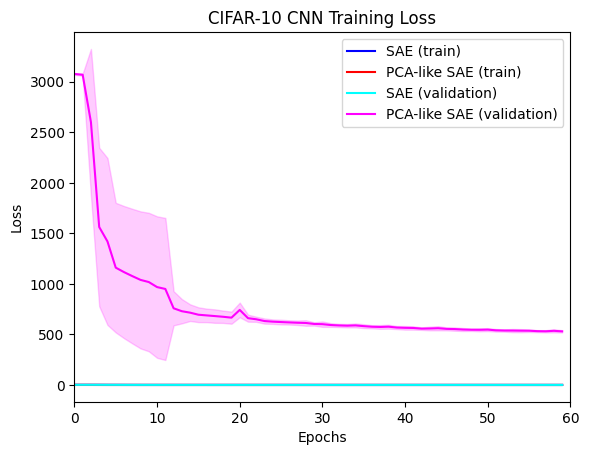

In [ ]:
plt.plot(train_loss_mean, label='SAE (train)', color='blue')
plt.fill_between(np.arange(len(train_loss_mean)), train_loss_mean - train_loss_std, train_loss_mean + train_loss_std, alpha=0.2, color='blue')
plt.plot(train_loss_mean_pca, label='PCA-like SAE (train)', color='red')
plt.fill_between(np.arange(len(train_loss_mean_pca)), train_loss_mean_pca - train_loss_std_pca, train_loss_mean_pca + train_loss_std_pca, alpha=0.2, color='red')
plt.plot(vali_loss_mean, label='SAE (validation)', color='cyan')
plt.fill_between(np.arange(len(vali_loss_mean)), vali_loss_mean - vali_loss_std, vali_loss_mean + vali_loss_std, alpha=0.2, color='cyan')
plt.plot(vali_loss_mean_pca, label='PCA-like SAE (validation)', color='magenta')
plt.fill_between(np.arange(len(vali_loss_mean_pca)), vali_loss_mean_pca - vali_loss_std_pca, vali_loss_mean_pca + vali_loss_std_pca, alpha=0.2, color='magenta')
plt.legend()
plt.title('CIFAR-10 CNN Training Loss')
plt.xlabel('Epochs')
plt.xlim(0, 60)
plt.ylabel('Loss')
plt.show()

In [ ]:

from rf_computation import compute_final_rfs


dae_rfs = compute_final_rfs(model_type='pca-init-sae', dataset='cifar', size_ls=None, num_models=1, num_epochs=60, base_path=os.path.expanduser('~/'))

SAE-LATENT-PCA-INIT-AFTER-PASS-FROZEN-2: 100%|██████████| 1/1 [00:31<00:00, 31.32s/it]


In [ ]:
sae_rfs = np.load('Results/cifar_sae_rfs.npy')
sae_rfs.shape

(10, 60, 128, 3, 32, 32)

In [ ]:
dae_rfs.shape

AttributeError: 'list' object has no attribute 'shape'

In [ ]:
# dae_rfs = np.load('Results/cifar_sae-latent-pca-init_final_rfs.npy')
dae_rfs = np.repeat(dae_rfs, 10, axis=0)
dae_rfs = np.repeat(dae_rfs[:, np.newaxis, :, :, :, :], 60, axis=1)
print(dae_rfs.shape)
np.save('Results/cifar_dae_rfs.npy', dae_rfs)

(10, 60, 128, 3, 32, 32)


In [ ]:
dae_rfs.shape

(10, 60, 128, 3, 32, 32)

In [ ]:
sae_rfs.shape

(10, 60, 128, 3, 32, 32)

In [ ]:
np.save('Results/cifar_sae_rfs.npy', sae_rfs)
np.save('Results/cifar_dae_rfs.npy', dae_rfs)

In [ ]:
from power_spectra import compute_power_spectra

sae_power_spectra, dae_power_spectra = compute_power_spectra(save_path_sae=None, save_path_dae=None, sae_rfs=sae_rfs, dae_rfs=dae_rfs, num_models=10, epoch=0)

100%|██████████| 10/10 [00:00<00:00, 21.88it/s]


FileNotFoundError: [Errno 2] No such file or directory: '/home/david/Documents/UNI_LOCAL/developing-autoencoders/paper_development_notebooks/paper_development_notebooks/Results/new/png/cifar_power_spectrum_individual.png'

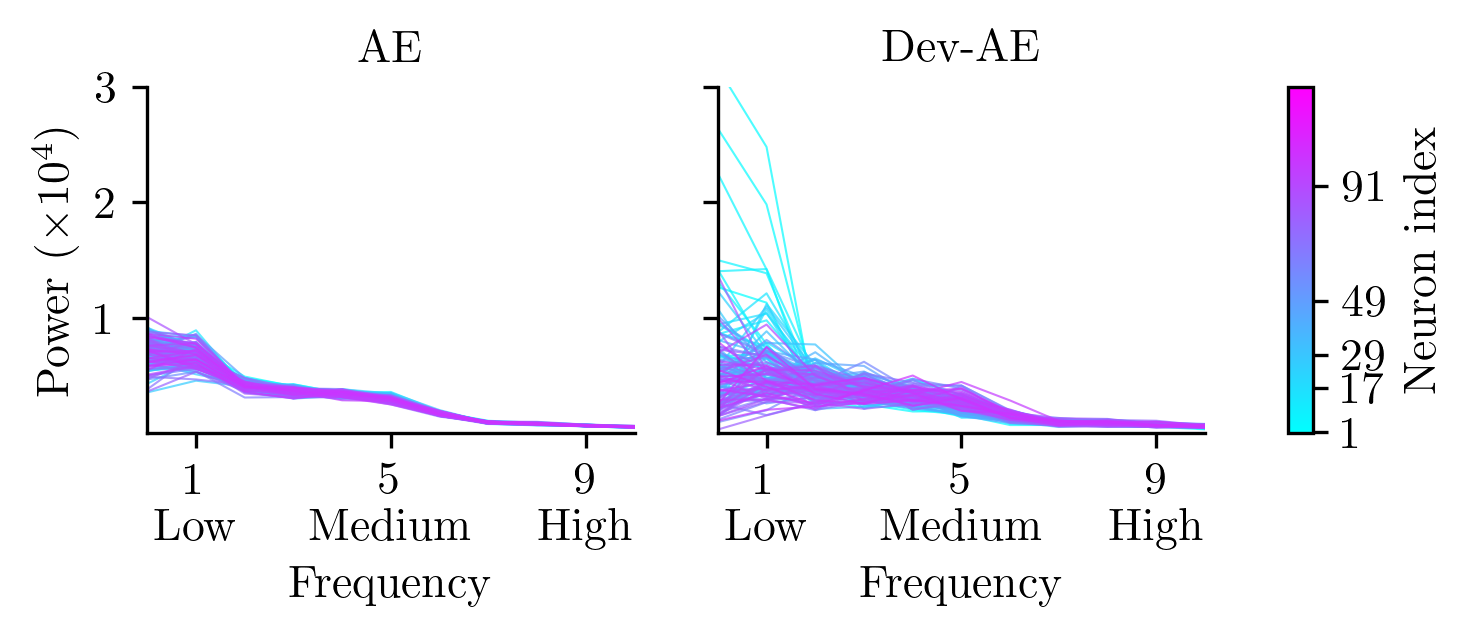

In [ ]:
from power_spectra import plot_power_spectra

plot_power_spectra(model_type='cifar', sae_power_spectra=sae_power_spectra, dae_power_spectra=dae_power_spectra, save_path='paper_development_notebooks/Results/new')

NameError: name 'fig' is not defined

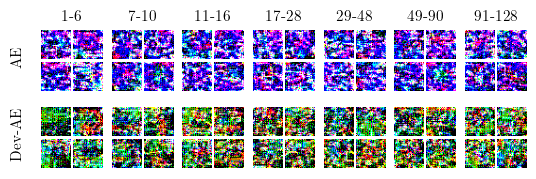

In [ ]:
from plot_example_rfs import plot_example_rfs

fig = plt.figure(figsize=(6.26, 1.9))
ax = fig.add_subplot(111)
plot_example_rfs(ax, dataset='cifar', epoch_idx=59)
plt.close(fig)